In [1]:
from pathlib import Path
import pandas as pd

air_file = Path.cwd() / "Data" / "Team Luft Data.xlsx"
air_df = pd.read_excel(air_file, sheet_name="Data")

print(f"Loaded {air_df.shape[0]} rows and {air_df.shape[1]} columns")
air_df.head()

Loaded 538 rows and 29 columns


,Team luft,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Prøve-ID ...,Lokasjon (DDM),Høyde over bakken,Dato utplassert,Tidspunkt utplassert,Dato innsamlet,Tidspunkt innsamlet,Trafikkmengde,Vindforhold,Støv/ forurensing,...,Kommentarer,Filter tilstede (1)/ filter mistet (0),NaN,Gjennomsnittlig nedbør per døgn (mm),Total mengde nedbør (mm),Gjennomsnittlig høyeste middelvind per døgn (m/s),Gjennomsnittlig middeltemperatur per døgn (°C),Maksimumstemperatur i perioden (°C),Minimumstemperatur i perioden (°C),Bilde av lokasjonen


In [13]:
# Reload raw data, drop first five rows, then use the next row as column headers.
air_file = Path.cwd() / "Data" / "Team Luft Data.xlsx"
air_df = pd.read_excel(air_file, sheet_name="Data", header=None)

air_df = air_df.iloc[5:].reset_index(drop=True)
air_df.columns = air_df.iloc[0].astype(str).str.strip()
air_df = air_df.iloc[1:].reset_index(drop=True)

# Normalize DDM seconds notation: convert two apostrophes ('') to double-quote (").
location_col = "Lokasjon (DDM)"
loc_text = air_df[location_col].astype(str)
replaced_count = loc_text.str.count("''").sum()
air_df[location_col] = loc_text.str.replace("''", '"', regex=False)

print(f"Cleaned dataframe shape: {air_df.shape}")
print(f"First column header: {air_df.columns[0]}")
print(f"Replaced DDM double-apostrophes: {int(replaced_count)}")
air_df.head()

Cleaned dataframe shape: (533, 29)
First column header: Prøve-ID                                                     Datasett 1 og Datasett 3;
Replaced DDM double-apostrophes: 248


,Prøve-ID Datasett 1 og Datasett 3;,Lokasjon (DDM),Høyde over bakken,Dato utplassert,Tidspunkt utplassert,Dato innsamlet,Tidspunkt innsamlet,Trafikkmengde,Vindforhold,Støv/ forurensing,...,Kommentarer,Filter tilstede (1)/ filter mistet (0),nan,Gjennomsnittlig nedbør per døgn (mm),Total mengde nedbør (mm),Gjennomsnittlig høyeste middelvind per døgn (m/s),Gjennomsnittlig middeltemperatur per døgn (°C),Maksimumstemperatur i perioden (°C),Minimumstemperatur i perioden (°C),Bilde av lokasjonen
0,LT1A,"63°25'21.2""N 10°20'57.06""E","1,6 m",29.06.2026,15:07:00,NaN,NaN,Ingen,Åpent/moderat,Lite,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LT1B,"63°25'21.2""N 10°20'57.06""E","1,6 m",29.06.2026,15:07:00,NaN,NaN,Ingen,Åpent/moderat,Lite,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LT1C,"63°25'21.2""N 10°20'57.06""E","0,8 m",29.06.2026,15:07:00,NaN,NaN,Ingen,Åpent/moderat,Lite,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LT1D,"63°25'21.2""N 10°20'57.06""E","0,8 m",29.06.2026,15:07:00,NaN,NaN,Ingen,Åpent/moderat,Lite,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LT2A,"63°25'15.24""N 10°20'56.34""E","1,6 m",29.06.2026,15:17:00,06.07.2026,10:29:00,Ingen,Skjermet/lite,Lite,...,NaN,1,NaN,4.1875,33.5,4.725,13.275,22.5,5.6,NaN


In [14]:
# Create partikler_per_cm^2_uke using Antall døgn ute and place it next to Partikkeltetthet.
partikkeltetthet_col = next(
    c for c in air_df.columns if str(c).strip().startswith("Partikkeltetthet (partikler per cm²")
)
dogn_col = "Antall døgn ute"
new_col = "partikler_per_cm^2_uke"

partikkeltetthet_num = pd.to_numeric(
    air_df[partikkeltetthet_col].astype(str).str.replace(",", ".", regex=False),
    errors="coerce",
)
dogn_num = pd.to_numeric(
    air_df[dogn_col].astype(str).str.replace(",", ".", regex=False),
    errors="coerce",
)

partikler_per_cm2_uke = pd.Series(index=air_df.index, dtype="float64")

mask_zero = partikkeltetthet_num == 0
mask_eq_7 = dogn_num == 7
mask_gt_7 = dogn_num > 7

partikler_per_cm2_uke.loc[mask_eq_7] = partikkeltetthet_num.loc[mask_eq_7]
partikler_per_cm2_uke.loc[mask_gt_7] = partikkeltetthet_num.loc[mask_gt_7] / (dogn_num.loc[mask_gt_7] / 7)
partikler_per_cm2_uke.loc[mask_zero] = 0

if new_col in air_df.columns:
    air_df = air_df.drop(columns=[new_col])

insert_idx = air_df.columns.get_loc(partikkeltetthet_col) + 1
air_df.insert(insert_idx, new_col, partikler_per_cm2_uke)

air_df[[partikkeltetthet_col, dogn_col, new_col]].head(10)

,Partikkeltetthet (partikler per cm²),Antall døgn ute,partikler_per_cm^2_uke
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,2.5,7,2.5
5,0,7,0.0
6,0,7,0.0
7,2.5,7,2.5
8,0,7,0.0
9,0,7,0.0


In [4]:
# Verify the weekly calculation for selected sample IDs.
sample_col = next(c for c in air_df.columns if str(c).strip().startswith("Prøve-ID"))
partikkeltetthet_col = next(
    c for c in air_df.columns if str(c).strip().startswith("Partikkeltetthet (partikler per cm²")
)
dogn_col = "Antall døgn ute"
weekly_col = "partikler_per_cm^2_uke"

ids_to_check = ["LT2A", "LT4A", "LI5B"]

check_df = air_df.loc[
    air_df[sample_col].astype(str).str.strip().isin(ids_to_check),
    [sample_col, partikkeltetthet_col, dogn_col, weekly_col],
].copy()

print("Found IDs:", sorted(check_df[sample_col].astype(str).str.strip().unique().tolist()))
missing_ids = [i for i in ids_to_check if i not in set(check_df[sample_col].astype(str).str.strip())]
if missing_ids:
    print("Missing IDs:", missing_ids)

check_df

Found IDs: ['LI5B', 'LT2A', 'LT4A']


,Prøve-ID Datasett 1 og Datasett 3;,Partikkeltetthet (partikler per cm²),Antall døgn ute,partikler_per_cm^2_uke
4,LT2A,2.5,7,2.5
12,LT4A,0,7,0.0
166,LI5B,7.5,21,2.5


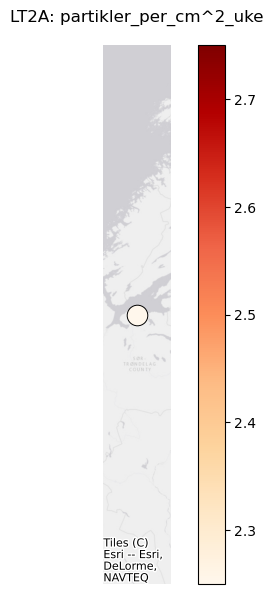

Entries in partikler_per_cm^2_uke: 412
LT2A decimal coordinates: lat=63.420900, lon=10.348983
LT2A partikler_per_cm^2_uke: 2.5


In [12]:
import re
import geopandas as gpd
import matplotlib.pyplot as plt

try:
    import contextily as cx
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "contextily"])
    import contextily as cx

sample_col = next(c for c in air_df.columns if str(c).strip().startswith("Prøve-ID"))
location_col = "Lokasjon (DDM)"
value_col = "partikler_per_cm^2_uke"


def ddm_to_decimal(ddm_text):
    # Example: 63°25'15.24"N 10°20'56.34"E
    pattern = r"(\d+)°(\d+)'([\d.]+)\"([NS])\s+(\d+)°(\d+)'([\d.]+)\"([EW])"
    m = re.match(pattern, str(ddm_text).strip())
    if not m:
        raise ValueError(f"Could not parse DDM coordinate: {ddm_text}")

    lat_deg, lat_min, lat_sec, lat_dir, lon_deg, lon_min, lon_sec, lon_dir = m.groups()
    lat = float(lat_deg) + float(lat_min) / 60 + float(lat_sec) / 3600
    lon = float(lon_deg) + float(lon_min) / 60 + float(lon_sec) / 3600

    if lat_dir == "S":
        lat *= -1
    if lon_dir == "W":
        lon *= -1

    return lat, lon

lt2a = air_df.loc[air_df[sample_col].astype(str).str.strip() == "LT2A"].copy()
if lt2a.empty:
    raise ValueError("LT2A was not found in air_df")

lat, lon = ddm_to_decimal(lt2a.iloc[0][location_col])
value = pd.to_numeric(pd.Series([lt2a.iloc[0][value_col]]), errors="coerce").iloc[0]

lt2a_gdf = gpd.GeoDataFrame(
    {"sample": ["LT2A"], "value": [value]},
    geometry=gpd.points_from_xy([lon], [lat]),
    crs="EPSG:4326",
)
lt2a_webmerc = lt2a_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(7, 7))
lt2a_webmerc.plot(
    ax=ax,
    column="value",
    cmap="OrRd",
    legend=True,
    markersize=220,
    edgecolor="black",
    linewidth=0.7,
)
cx.add_basemap(ax, source=cx.providers.Esri.WorldGrayCanvas)
ax.set_title("LT2A: partikler_per_cm^2_uke")
ax.set_axis_off()
plt.show()

entry_count = pd.to_numeric(air_df[value_col], errors="coerce").notna().sum()
print(f"Entries in {value_col}: {entry_count}")
print(f"LT2A decimal coordinates: lat={lat:.6f}, lon={lon:.6f}")
print(f"LT2A {value_col}: {value}")

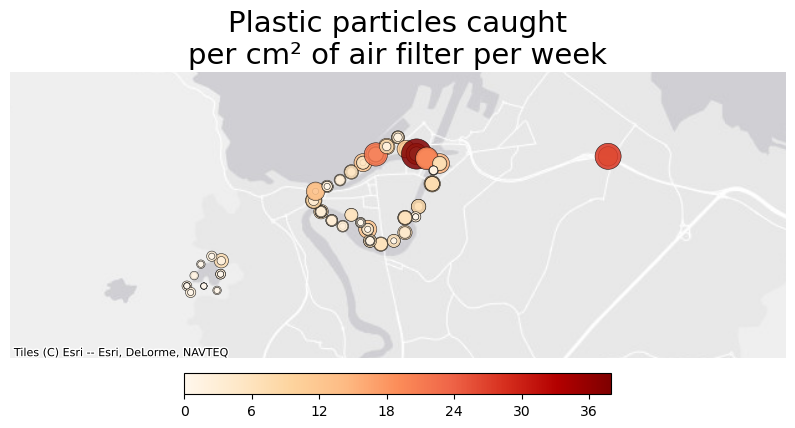

Mapped points: 230
Zero-valued points included: 60


In [20]:
import re
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

try:
    import contextily as cx
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "contextily"])
    import contextily as cx

sample_col = next(c for c in air_df.columns if str(c).strip().startswith("Prøve-ID"))
location_col = "Lokasjon (DDM)"
value_col = "partikler_per_cm^2_uke"


def ddm_to_decimal(ddm_text):
    # Example: 63°25'15.24"N 10°20'56.34"E
    pattern = r"(\d+)°(\d+)'([\d.]+)\"([NS])\s+(\d+)°(\d+)'([\d.]+)\"([EW])"
    m = re.match(pattern, str(ddm_text).strip())
    if not m:
        return None, None

    lat_deg, lat_min, lat_sec, lat_dir, lon_deg, lon_min, lon_sec, lon_dir = m.groups()

    lat = float(lat_deg) + float(lat_min) / 60 + float(lat_sec) / 3600
    lon = float(lon_deg) + float(lon_min) / 60 + float(lon_sec) / 3600

    if lat_dir == "S":
        lat *= -1
    if lon_dir == "W":
        lon *= -1

    return lat, lon

plot_df = air_df[[sample_col, location_col, value_col]].copy()
plot_df[value_col] = pd.to_numeric(plot_df[value_col], errors="coerce")

coords = plot_df[location_col].apply(ddm_to_decimal)
plot_df["lat"] = coords.apply(lambda x: x[0])
plot_df["lon"] = coords.apply(lambda x: x[1])

# Keep zero values; only drop rows without valid coordinates or value.
plot_df = plot_df.dropna(subset=["lat", "lon", value_col]).copy()

air_gdf = gpd.GeoDataFrame(
    plot_df,
    geometry=gpd.points_from_xy(plot_df["lon"], plot_df["lat"]),
    crs="EPSG:4326",
)

air_webmerc = air_gdf.to_crs(epsg=3857)

value_max = air_webmerc[value_col].max()
upper_even = int(np.ceil(value_max / 2.0) * 2)
tick_step = max(2, int(np.ceil(upper_even / 8)))
if tick_step % 2 != 0:
    tick_step += 1
colorbar_ticks = np.arange(0, upper_even + tick_step, tick_step)

fig, ax = plt.subplots(figsize=(10, 10))
air_webmerc.plot(
    ax=ax,
    column=value_col,
    cmap="OrRd",
    legend=True,
    legend_kwds={
        "orientation": "horizontal",
        "shrink": 0.55,
        "pad": 0.02,
        "ticks": colorbar_ticks,
    },
    markersize=air_webmerc[value_col] * 12 + 20,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.4,
)

# Zoom out further by expanding data bounds before adding the basemap.
xmin, ymin, xmax, ymax = air_webmerc.total_bounds
xpad = (xmax - xmin) * 0.42
ypad = (ymax - ymin) * 0.42
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

cx.add_basemap(ax, source=cx.providers.Esri.WorldGrayCanvas)
ax.set_title("Plastic particles caught\nper cm² of air filter per week", fontsize=21)
ax.set_axis_off()
plt.show()

print(f"Mapped points: {len(air_webmerc)}")
print(f"Zero-valued points included: {(air_webmerc[value_col] == 0).sum()}")

In [21]:
from pathlib import Path

output_dir = Path("Maps")
output_dir.mkdir(exist_ok=True)

output_file = output_dir / "air, particles per filter centimeter per week.png"
fig.savefig(output_file, dpi=300, bbox_inches="tight")
print(f"Map exported to: {output_file}")

Map exported to: Maps/air, particles per filter centimeter per week.png
